In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
df = pd.read_csv('train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [11]:
df.shape

(614, 13)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [34]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049,7024.705081
std,6109.041673,2926.248369,84.107233,64.428629,0.352339,6458.663872
min,150.000000,0.000000,9.000000,12.000000,0.000000,1442.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000,4166.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000,5416.500000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000,7521.750000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000,81000.000000


In [9]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='str')

In [15]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [20]:
# dealing with the missing data 
#gender we are going to use the mode function 
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
df

C:\Users\Priya BV\AppData\Local\Temp\ipykernel_15600\806641937.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [22]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [23]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())

df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [24]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

<Axes: xlabel='Loan_Status'>

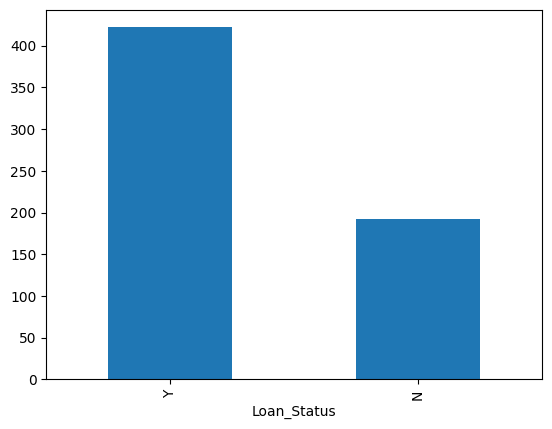

In [25]:
df['Loan_Status'].value_counts().plot( kind ="bar")

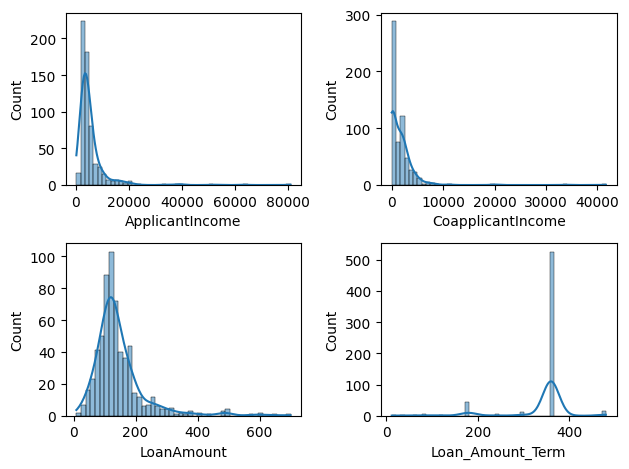

In [27]:
def ploting(var, num):
    plt.subplot(2,2,num)
    sns.histplot(df[var], kde = True)

ploting('ApplicantIncome',1)
ploting('CoapplicantIncome',2)
ploting('LoanAmount',3)
ploting('Loan_Amount_Term',4)
plt.tight_layout()


In [28]:
df["ApplicantIncome"].describe()

count      614.000000
mean      5403.459283
std       6109.041673
min        150.000000
25%       2877.500000
50%       3812.500000
75%       5795.000000
max      81000.000000
Name: ApplicantIncome, dtype: float64

In [29]:
df["CoapplicantIncome"].describe()

count      614.000000
mean      1621.245798
std       2926.248369
min          0.000000
25%          0.000000
50%       1188.500000
75%       2297.250000
max      41667.000000
Name: CoapplicantIncome, dtype: float64

In [30]:
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

In [31]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,2900.0
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,4106.0
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,8312.0
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,7583.0


In [32]:
df["Loan_Amount_Term"].describe()

count    614.000000
mean     342.410423
std       64.428629
min       12.000000
25%      360.000000
50%      360.000000
75%      360.000000
max      480.000000
Name: Loan_Amount_Term, dtype: float64

In [33]:
df["LoanAmount"].describe()

count    614.000000
mean     145.752443
std       84.107233
min        9.000000
25%      100.250000
50%      128.000000
75%      164.750000
max      700.000000
Name: LoanAmount, dtype: float64

In [38]:
df.columns


Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'TotalIncome'],
      dtype='str')

<Axes: xlabel='Gender', ylabel='count'>

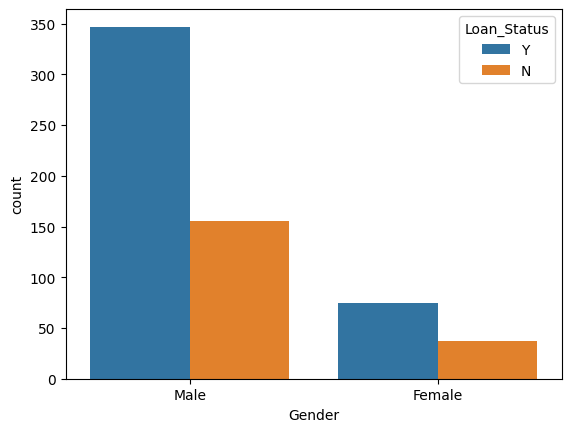

In [37]:
#countplot is used for categorical data analysis
sns.countplot(x = df['Gender'],hue = df['Loan_Status'])

<Axes: xlabel='Married', ylabel='count'>

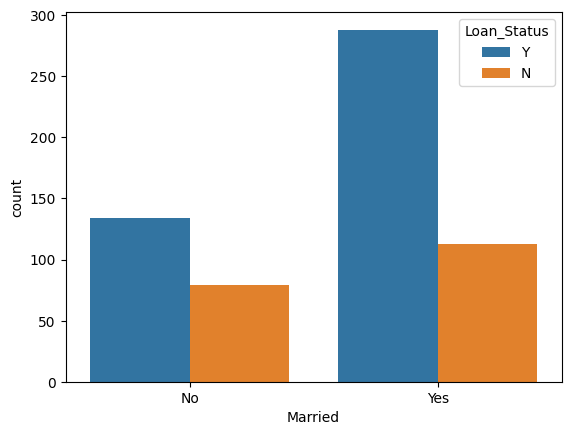

In [39]:
sns.countplot(x = df['Married'],hue = df['Loan_Status'])

<Axes: xlabel='Dependents', ylabel='count'>

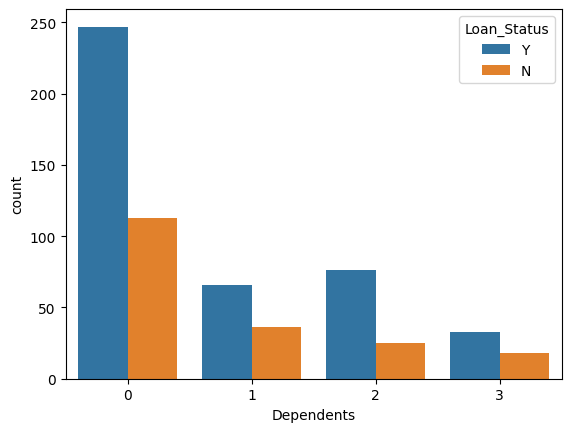

In [42]:
df["Dependents"] = df["Dependents"].replace("3+", 3)
sns.countplot(x = df['Dependents'],hue = df['Loan_Status'])

<Axes: xlabel='Self_Employed', ylabel='count'>

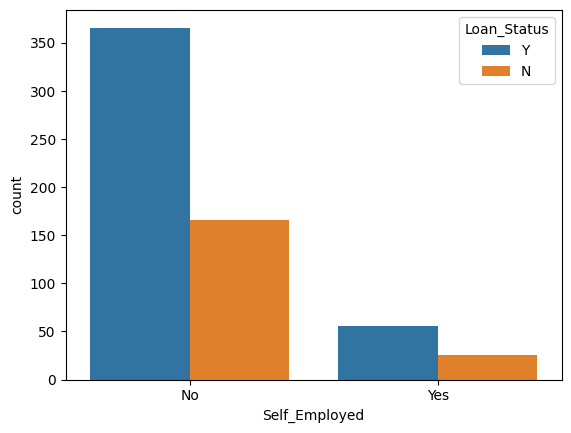

In [45]:
sns.countplot(x = df['Self_Employed'],hue = df['Loan_Status'])



<Axes: xlabel='Credit_History', ylabel='count'>

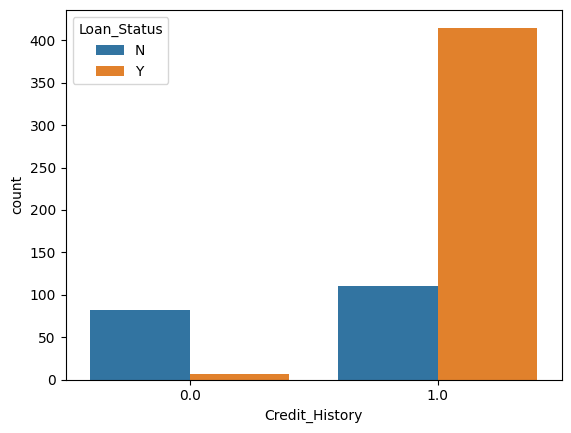

In [43]:
sns.countplot(x = df['Credit_History'],hue = df['Loan_Status'])

<Axes: xlabel='Property_Area', ylabel='count'>

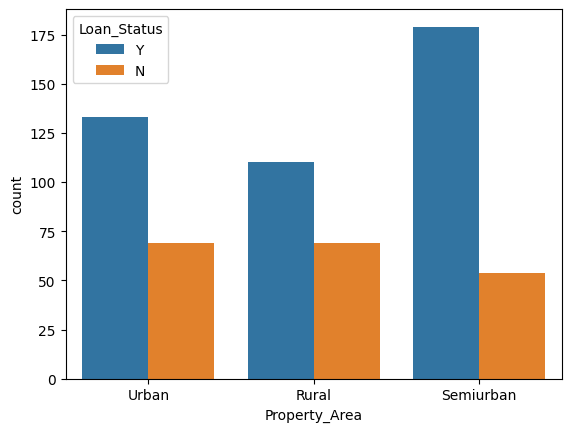

In [53]:
sns.countplot(x = df['Property_Area'],hue = df['Loan_Status'])

In [51]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0


<Axes: >

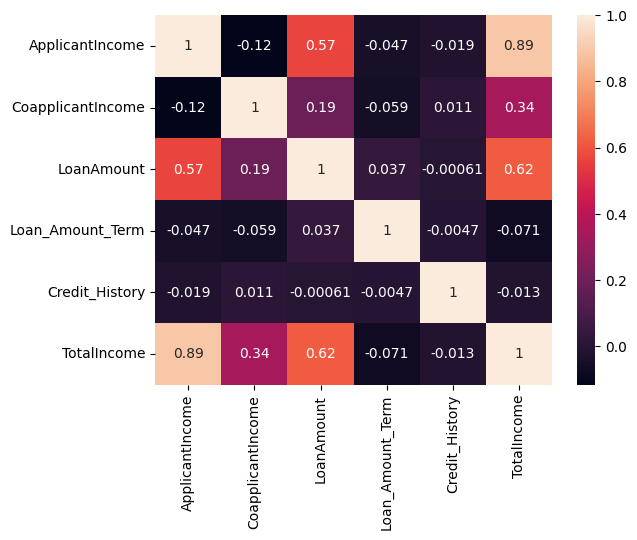

In [52]:
sns.heatmap(df.corr(numeric_only = True),annot = True)

In [56]:
#encoding the values for 'Gender', 'Married', 'Dependents', 'Education','Self_Employed' 'Credit_History', 'Property_Area', 'Loan_Status'
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Gender','Married','Education','Self_Employed']:
    df[col] = le.fit_transform(df[col])

df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,Rural,Y,2900.0
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,Rural,Y,4106.0
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,Urban,Y,8312.0
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,Urban,Y,7583.0


In [131]:
df_encode = pd.get_dummies(df, drop_first = True,dtype = int)
df_encode

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,Dependents_0,Dependents_1,Dependents_2,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,1,0,0,0,5849,0.0,128.0,360.0,1.0,5849.0,1,0,0,0,1,1
1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,6091.0,0,1,0,0,0,0
2,1,1,0,1,3000,0.0,66.0,360.0,1.0,3000.0,1,0,0,0,1,1
3,1,1,1,0,2583,2358.0,120.0,360.0,1.0,4941.0,1,0,0,0,1,1
4,1,0,0,0,6000,0.0,141.0,360.0,1.0,6000.0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,2900,0.0,71.0,360.0,1.0,2900.0,1,0,0,0,0,1
610,1,1,0,0,4106,0.0,40.0,180.0,1.0,4106.0,0,0,0,0,0,1
611,1,1,0,0,8072,240.0,253.0,360.0,1.0,8312.0,0,1,0,0,1,1
612,1,1,0,0,7583,0.0,187.0,360.0,1.0,7583.0,0,0,1,0,1,1


In [132]:
#standard Scaling 
from sklearn.preprocessing import StandardScaler 
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term','TotalIncome']
scaler = StandardScaler()
df_encode[numeric_cols] = scaler.fit_transform(df_encode[numeric_cols])
df_encode.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,Dependents_0,Dependents_1,Dependents_2,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,1,0,0,0,0.072991,-0.554487,-0.211241,0.273231,1.0,-0.182184,1,0,0,0,1,1
1,1,1,0,0,-0.134412,-0.038732,-0.211241,0.273231,1.0,-0.144684,0,1,0,0,0,0
2,1,1,0,1,-0.393747,-0.554487,-0.948996,0.273231,1.0,-0.623656,1,0,0,0,1,1
3,1,1,1,0,-0.462062,0.251980,-0.306435,0.273231,1.0,-0.322885,1,0,0,0,1,1
4,1,0,0,0,0.097728,-0.554487,-0.056551,0.273231,1.0,-0.158785,1,0,0,0,1,1


In [59]:
#i have an another set of dataset i need to perdict the loan status for this -> bankloan.csv file 
# i need to follow the same steps of missing values , encode , scaling 
new_df = pd.read_csv('bankloan.csv')
new_df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    object 
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    str    
 11  Loan_Status        614 non-null    str    
 12  TotalIncome        614 non-null    float64
dtypes: float64(5), int64(5), object(1), str(2)
memory usage: 62.5+ KB


In [101]:
new_df.describe()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,362.000000,361.000000,338.000000
mean,0.839237,0.634877,0.228883,0.226158,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,0.442036,0.482122,0.420687,0.548791,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,28.000000,6.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,1.000000,1.000000,0.000000,0.000000,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,1.000000,1.000000,0.000000,0.000000,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,2.000000,1.000000,1.000000,2.000000,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [102]:
new_df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='str')

In [103]:
new_df.isnull().sum()

Gender                0
Married               0
Dependents           10
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [109]:
#filling the misiing vlues 
new_df["Dependents"] = new_df["Dependents"].fillna(new_df["Dependents"].mode()[0])
new_df["LoanAmount"] = new_df["LoanAmount"].fillna(new_df["LoanAmount"].median())

new_df["Loan_Amount_Term"] = new_df["Loan_Amount_Term"].fillna(new_df["Loan_Amount_Term"].median())

new_df["Credit_History"] = new_df["Credit_History"].fillna(new_df["Credit_History"].mode()[0])
new_df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,1,0,0,0,5720,0,110.0,360.0,1.0,Urban
1,1,1,1,0,0,3076,1500,126.0,360.0,1.0,Urban
2,1,1,2,0,0,5000,1800,208.0,360.0,1.0,Urban
3,1,1,2,0,0,2340,2546,100.0,360.0,1.0,Urban
4,1,0,0,1,0,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
362,1,1,3+,1,1,4009,1777,113.0,360.0,1.0,Urban
363,1,1,0,0,0,4158,709,115.0,360.0,1.0,Urban
364,1,0,0,0,0,3250,1993,126.0,360.0,1.0,Semiurban
365,1,1,0,0,0,5000,2393,158.0,360.0,1.0,Rural


In [110]:
new_df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

In [111]:
#encoding the values for 'Gender', 'Married', 'Dependents', 'Education','Self_Employed' 'Credit_History', 'Property_Area', 'Loan_Status'
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Gender','Married','Education','Self_Employed']:
    new_df[col] = le.fit_transform(new_df[col])

new_df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,1,0,0,0,5720,0,110.0,360.0,1.0,Urban
1,1,1,1,0,0,3076,1500,126.0,360.0,1.0,Urban
2,1,1,2,0,0,5000,1800,208.0,360.0,1.0,Urban
3,1,1,2,0,0,2340,2546,100.0,360.0,1.0,Urban
4,1,0,0,1,0,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
362,1,1,3+,1,1,4009,1777,113.0,360.0,1.0,Urban
363,1,1,0,0,0,4158,709,115.0,360.0,1.0,Urban
364,1,0,0,0,0,3250,1993,126.0,360.0,1.0,Semiurban
365,1,1,0,0,0,5000,2393,158.0,360.0,1.0,Rural


In [114]:
new_df['Dependents'] = new_df['Dependents'].replace('3+', 3)
new_df['Dependents'].value_counts()
new_df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,1,0,0,0,5720,0,110.0,360.0,1.0,Urban
1,1,1,1,0,0,3076,1500,126.0,360.0,1.0,Urban
2,1,1,2,0,0,5000,1800,208.0,360.0,1.0,Urban
3,1,1,2,0,0,2340,2546,100.0,360.0,1.0,Urban
4,1,0,0,1,0,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
362,1,1,3,1,1,4009,1777,113.0,360.0,1.0,Urban
363,1,1,0,0,0,4158,709,115.0,360.0,1.0,Urban
364,1,0,0,0,0,3250,1993,126.0,360.0,1.0,Semiurban
365,1,1,0,0,0,5000,2393,158.0,360.0,1.0,Rural


In [115]:
new_df_encode = pd.get_dummies(new_df, drop_first = True,dtype = int)
new_df_encode

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Dependents_0,Dependents_1,Dependents_2,Property_Area_Semiurban,Property_Area_Urban
0,1,1,0,0,5720,0,110.0,360.0,1.0,1,0,0,0,1
1,1,1,0,0,3076,1500,126.0,360.0,1.0,0,1,0,0,1
2,1,1,0,0,5000,1800,208.0,360.0,1.0,0,0,1,0,1
3,1,1,0,0,2340,2546,100.0,360.0,1.0,0,0,1,0,1
4,1,0,1,0,3276,0,78.0,360.0,1.0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,1,1,1,1,4009,1777,113.0,360.0,1.0,0,0,0,0,1
363,1,1,0,0,4158,709,115.0,360.0,1.0,1,0,0,0,1
364,1,0,0,0,3250,1993,126.0,360.0,1.0,1,0,0,1,0
365,1,1,0,0,5000,2393,158.0,360.0,1.0,1,0,0,0,0


In [121]:
new_df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='str')

In [124]:
#standard Scaling 
from sklearn.preprocessing import StandardScaler 
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term']
scaler = StandardScaler()
new_df_encode[numeric_cols] = scaler.fit_transform(new_df_encode[numeric_cols])
new_df_encode.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Dependents_0,Dependents_1,Dependents_2,Property_Area_Semiurban,Property_Area_Urban
0,1,1,0,0,0.186461,-0.673335,-0.426780,0.266022,1.0,1,0,0,0,1
1,1,1,0,0,-0.352692,-0.029848,-0.163953,0.266022,1.0,0,1,0,0,1
2,1,1,0,0,0.039641,0.098849,1.183033,0.266022,1.0,0,0,1,0,1
3,1,1,0,0,-0.502774,0.418877,-0.591047,0.266022,1.0,0,0,1,0,1
4,1,0,1,0,-0.311909,-0.673335,-0.952433,0.266022,1.0,1,0,0,0,1


In [138]:
df.head()
df_encode = pd.get_dummies(df, drop_first = True,dtype = int)
df_encode

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Dependents_0,Dependents_1,Dependents_2,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,1,0,0,0,5849,0.0,128.0,360.0,1.0,1,0,0,0,1,1
1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,1,0,0,0,0
2,1,1,0,1,3000,0.0,66.0,360.0,1.0,1,0,0,0,1,1
3,1,1,1,0,2583,2358.0,120.0,360.0,1.0,1,0,0,0,1,1
4,1,0,0,0,6000,0.0,141.0,360.0,1.0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,2900,0.0,71.0,360.0,1.0,1,0,0,0,0,1
610,1,1,0,0,4106,0.0,40.0,180.0,1.0,0,0,0,0,0,1
611,1,1,0,0,8072,240.0,253.0,360.0,1.0,0,1,0,0,1,1
612,1,1,0,0,7583,0.0,187.0,360.0,1.0,0,0,1,0,1,1


In [142]:
X = df_encode.drop('Loan_Status_Y', axis=1)
y = df_encode['Loan_Status_Y']

In [143]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [144]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [149]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [150]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7886178861788617


In [151]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[18 25]
 [ 1 79]]
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [158]:
X_new_scaled = scaler.transform(new_df_encode)
predictions = model.predict(X_new_scaled)

In [159]:
predictions = le.inverse_transform(predictions)

In [160]:
new_df['Loan_Status'] = predictions

In [161]:
new_df.to_csv('bankloan_with_predictions.csv', index=False)

In [162]:
new_df['Loan_Status'].value_counts()

Loan_Status
Y    363
N      4
Name: count, dtype: int64